In [1]:
 import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import accuracy_score, log_loss, classification_report

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#1.1 Добавьте собственную реализацию вычисления Accuracy

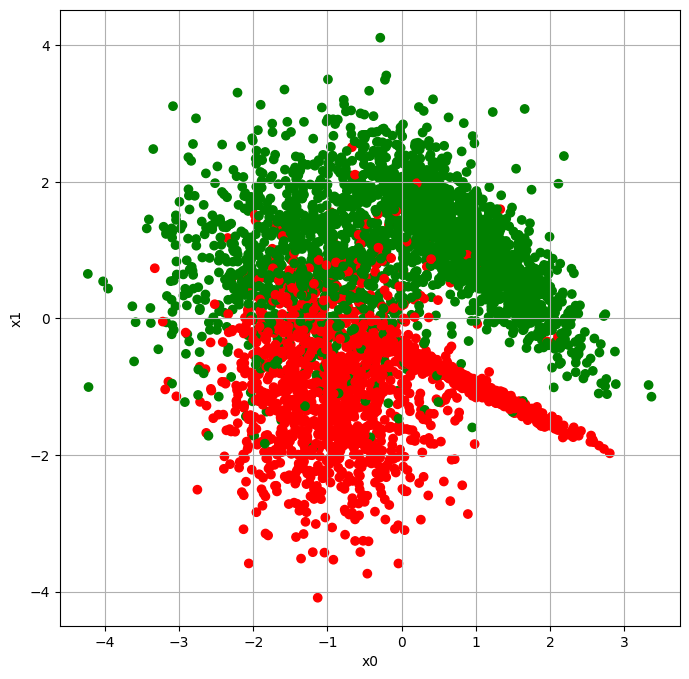

In [2]:
classes = datasets.make_classification(
    n_samples=5000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=120
)

colors = ListedColormap(['red', 'blue', 'green'])

plt.figure(figsize=(8, 8))
plt.scatter([x[0] for x in classes[0]], [x[1] for x in classes[0]], c=classes[1], cmap=colors)
plt.grid()
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

In [3]:
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(classes[0], classes[1], test_size=0.2, random_state=1)
X_val_tr, X_test_tr, y_val_tr, y_test_tr = train_test_split(X_test_tr, y_test_tr,test_size=0.5,random_state=1)

lr = LogisticRegression()
lr.fit(X_train_tr, y_train_tr)
y_pred = lr.predict_proba(X_val_tr)

tr = 0.5
y_p = (y_pred[:, 1] > tr).astype(int)

correct = np.sum((y_val_tr == 1).astype('int') == y_p)
accuracy = correct / len(y_val_tr)

print('Ответы модели:', y_p)
print('Правильные ответы:', y_val_tr)
print('Верных ответов:', correct)
print('Всего объектов:', len(y_val_tr))
print('Accuracy:', accuracy)

Ответы модели: [0 0 1 1 1 1 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1
 0 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1
 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1
 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1
 1 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 1
 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0
 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1
 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1
 1 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 0 0
 0 0 1 1 0 1 0 1 0 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 0 1 1 1 1 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 1
 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 0 0 0 1 0
 1 1 1 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0
 1 1 0 0 0

#1.2 Определите лучший уровень значений Accuracy для текущего примера

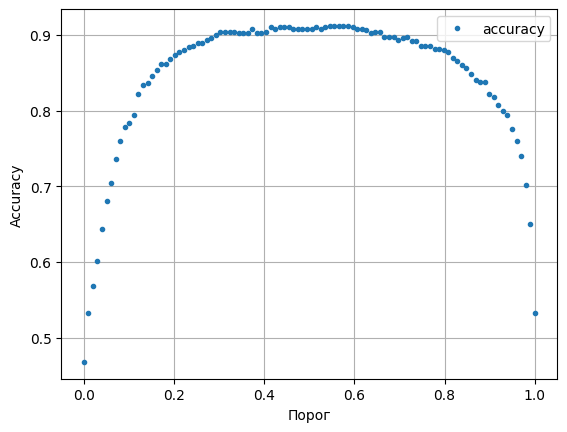

In [4]:
acc = []

for tr in np.linspace(0, 1, 100):
    y_p = (y_pred[:, 1] > tr).astype(int)

    correct = np.sum((y_val_tr == 1).astype('int') == y_p)
    accuracy = correct / len(y_val_tr)

    acc += [[tr, accuracy]]

acc = np.array(acc)

plt.plot(acc[:, 0], acc[:, 1], '.', label='accuracy')
plt.grid()
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [5]:
best = np.argmax(acc[:, 1])
best_tr = acc[best, 0]
best_accuracy = acc[best, 1]

print('Лучший порог:', best_tr)
print('Лучший Accuracy:', best_accuracy)

Лучший порог: 0.5454545454545455
Лучший Accuracy: 0.912


#1.3 определите уровень Accuracy по тестовой выборке на лучшем по тренировояной уровне оценки

In [6]:
y_pred_bt = lr.predict_proba(X_test_tr)
y_p_bt = (y_pred_bt[:, 1] > best_tr).astype(int)

correct_bt = np.sum((y_test_tr == 1).astype('int') == y_p_bt)
accuracy_bt = correct_bt / len(y_test_tr)

print('Правильных ответов:', correct_bt)
print('Всего объектов:', len(y_test_tr))
print('Accuracy на тестовой выборке:', accuracy_bt)

Правильных ответов: 455
Всего объектов: 500
Accuracy на тестовой выборке: 0.91


#1.4 Оцените (постройте кривые изменения Accuracy и потерь для тестовой(отложенной выборки) ) поведение модели при использовании одной и 2-х координат (х0,х1)

In [7]:
lr.fit(X_train_tr[:, 0:1], y_train_tr)
y_pred = lr.predict_proba(X_test_tr[:, 0:1])

acc1 = []
loss1 = []

for tr in np.linspace(0, 1, 100):

    y_p = (y_pred[:, 1] > tr).astype(int)

    correct = np.sum((y_test_tr == 1).astype('int') == y_p)
    accuracy = correct / len(y_test_tr)

    acc1 += [[tr, accuracy]]
    loss1 += [[tr, log_loss(y_test_tr, y_p)]]

acc1 = np.array(acc1)
loss1 = np.array(loss1)

In [8]:
lr.fit(X_train_tr, y_train_tr)
y_pred = lr.predict_proba(X_test_tr)

acc2 = []
loss2 = []

for tr in np.linspace(0, 1, 100):

    y_p = (y_pred[:, 1] > tr).astype(int)

    correct = np.sum((y_test_tr == 1).astype('int') == y_p)
    accuracy = correct / len(y_test_tr)

    acc2 += [[tr, accuracy]]
    loss2 += [[tr, log_loss(y_test_tr, y_p)]]

acc2 = np.array(acc2)
loss2 = np.array(loss2)

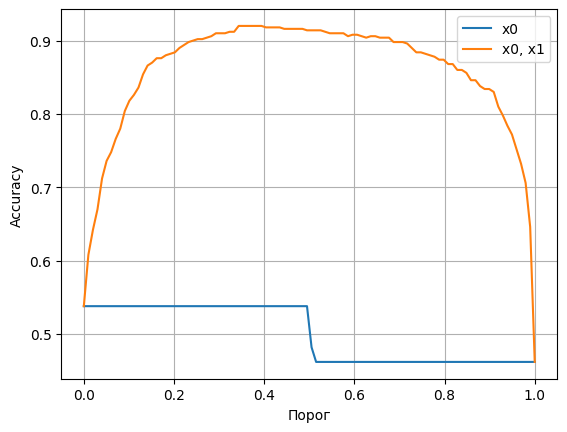

In [9]:
plt.plot(acc1[:, 0], acc1[:, 1], label='x0')
plt.plot(acc2[:, 0], acc2[:, 1], label='x0, x1')

plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()

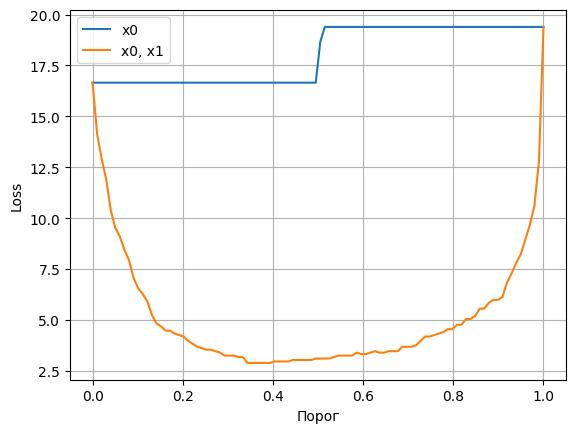

In [10]:
plt.plot(loss1[:, 0], loss1[:, 1], label='x0')
plt.plot(loss2[:, 0], loss2[:, 1], label='x0, x1')

plt.xlabel('Порог')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

#1.5 зафиксируйте результаты в таблице и сделайте выводы

In [11]:
best1 = np.argmax(acc1[:, 1])
best2 = np.argmax(acc2[:, 1])

results = pd.DataFrame({
    'Признаки': ['x0', 'x0, x1'],
    'Лучший порог': [acc1[best1, 0], acc2[best2, 0]],
    'Максимальный Accuracy': [acc1[best1, 1], acc2[best2, 1]],
    'Loss': [loss1[best1, 1], loss2[best2, 1]]
})

results

,Признаки,Лучший порог,Максимальный Accuracy,Loss
0,x0,0.000000,0.538,16.652168
1,"x0, x1",0.343434,0.920,2.883492


Вывод:

При использовании только одного признака x0 качество классификации оказалось низким. Значением Accuracy находится примерно на уровне случайного угадывания.

При использовании двух признаков x0 и x1 Accuracy значительно увеличивается, а значение Loss уменьшается.Это показывает, что второй признак содержит важную информацию для разделения классов

Следовательно, использование двух признаков позволяет модели классифицировать объекты заметно точнее, чем при использовании только 1 координаты

#2.0 Загрузить набор Breast Cancer Wisconsin: data = datasets.load_breast_cancer(), X, y = data.data, data.target. Признаки описывают характеристики клеточных ядер; целевая переменная задаёт два класса: 0 — злокачественное, 1 — доброкачественное новообразование. Используйте все числовые признаки. При переносе кода задания 1 порог применяется к вероятности класса 1 (доброкачественного новообразования).




In [12]:
data = datasets.load_breast_cancer()

X, y = data.data, data.target

print('Размер X:', X.shape)
print('Размер y:', y.shape)
print(np.unique(y))

Размер X: (569, 30)
Размер y: (569,)
[0 1]


#2.1 Проведите эксперимент(для кода из результата задания 1) с изменением шага по порогу в диапазоне (0.001, 0.1) (10 вариантов) по всеп признакам численного типа


In [13]:
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X, y, test_size=0.2, random_state=1)
X_val_tr, X_test_tr, y_val_tr, y_test_tr = train_test_split(X_test_tr, y_test_tr, test_size=0.5, random_state=1)

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_tr, y_train_tr)
y_pred = lr.predict_proba(X_val_tr)

tr = 0.5
y_p = (y_pred[:, 1] > tr).astype(int)
print(y_p)
accuracy_score((y_val_tr==1).astype('int'),y_p)

[1 0 0 1 1 1 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0
 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1]


0.9298245614035088

In [14]:
steps = np.linspace(0.001, 0.1, 10)
results = []

for step in steps:
    acc = []
    for tr in np.arange(0, 1 + step, step):
        y_p = (y_pred[:, 1] > tr).astype(int)
        accuracy = accuracy_score((y_val_tr == 1).astype('int'), y_p)

        acc += [[tr, accuracy]]

    acc = np.array(acc)
    best = np.argmax(acc[:, 1])
    best_tr = acc[best, 0]
    best_accuracy = acc[best, 1]

    results += [[step, best_tr, best_accuracy]]

results = np.array(results)

results

array([[0.001     , 0.378     , 0.94736842],
       [0.012     , 0.384     , 0.94736842],
       [0.023     , 0.391     , 0.94736842],
       [0.034     , 0.408     , 0.94736842],
       [0.045     , 0.405     , 0.94736842],
       [0.056     , 0.392     , 0.94736842],
       [0.067     , 0.402     , 0.94736842],
       [0.078     , 0.39      , 0.94736842],
       [0.089     , 0.356     , 0.92982456],
       [0.1       , 0.4       , 0.94736842]])

#2.2 зафиксируйте результаты в таблице и сделайте выводы


- сформируем отчет о классификации



In [15]:
y_pred = lr.predict_proba(X_test_tr)[:,1]
y_p = (y_pred[:] > best_tr).astype(int)

print(classification_report(y_test_tr, y_p))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93        16
           1       0.95      1.00      0.98        41

    accuracy                           0.96        57
   macro avg       0.98      0.94      0.95        57
weighted avg       0.97      0.96      0.96        57



- проведем эксперимент для нескольких перезапусков алгоритма (К) и различных сочетаний значений гиперпараметров (tol, max_iter). Сделаем сеточный поиск в пространстве вариантов для множества К = 10 реализаций

In [16]:
tols = [0.1, 0.01, 0.001, 0.0001]
max_iters = [10, 100, 1000, 10000]

grid_results = []

for tol in tols:
    for max_iter in max_iters:

        acc_k = []

        for k in range(10):
          X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X, y, test_size=0.2, random_state=k)
          X_val_tr, X_test_tr, y_val_tr, y_test_tr = train_test_split(X_test_tr, y_test_tr, test_size=0.5, random_state=k)

          lr = LogisticRegression(tol=tol,max_iter=max_iter)
          lr.fit(X_train_tr, y_train_tr)
          y_p = lr.predict(X_val_tr)

          accuracy = accuracy_score(y_val_tr, y_p)

          acc_k.append(accuracy)

        grid_results += [[tol, max_iter, np.mean(acc_k)]]

grid_results = pd.DataFrame(
    grid_results,
    columns=['tol', 'max_iter', 'Средний Accuracy']
)

table = grid_results.pivot(
    index='tol',
    columns='max_iter',
    values='Средний Accuracy'
)

table

max_iter,10,100,1000,10000
tol,,,,
0.0001,0.894737,0.929825,0.938596,0.942105
0.0010,0.894737,0.929825,0.936842,0.938596
0.0100,0.894737,0.929825,0.940351,0.940351
0.1000,0.894737,0.931579,0.931579,0.931579


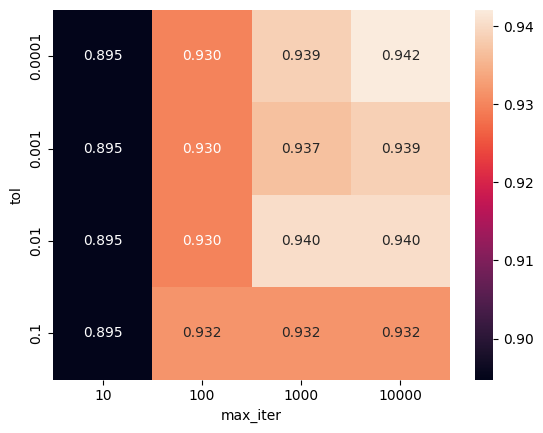

In [17]:
sns.heatmap(table, annot=True, fmt='.3f')
plt.xlabel('max_iter')
plt.ylabel('tol')
plt.show()

Вывод:

необходимо более 100 итераций и не менее 0.1 tol. Выборка примеров сбалансирована, и применение метрик типа accuracy обоснован


#3 зафиксируйте результаты в таблице и сделайте выводы


- провести генерацию порогового классификатора

In [18]:
data = datasets.load_iris()
X, y = data.data, data.target

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X, y, test_size=0.2, random_state=1)
X_val_tr, X_test_tr, y_val_tr, y_test_tr = train_test_split(X_test_tr, y_test_tr, test_size=0.5, random_state=1)

In [19]:
lr = LogisticRegression()
lr.fit(X_train_tr, y_train_tr)
y_pred = lr.predict_proba(X_test_tr)

score = 0 * y_pred[:, 0] + 1 * y_pred[:, 1] + 2 * y_pred[:, 2]

y_p = []

for value in score:
    if value < 0.5:
        y_p.append(0)
    elif value < 1.5:
        y_p.append(1)
    else:
        y_p.append(2)

y_p = np.array(y_p)

print("Предсказанные классы:")
print(y_p)

print("\nИстинные классы:")
print(y_test_tr)

Предсказанные классы:
[1 1 1 0 1 1 0 0 2 2 0 2 1 1 2]

Истинные классы:
[1 1 1 0 1 1 0 0 2 1 0 2 1 1 2]


- провести анализ результата

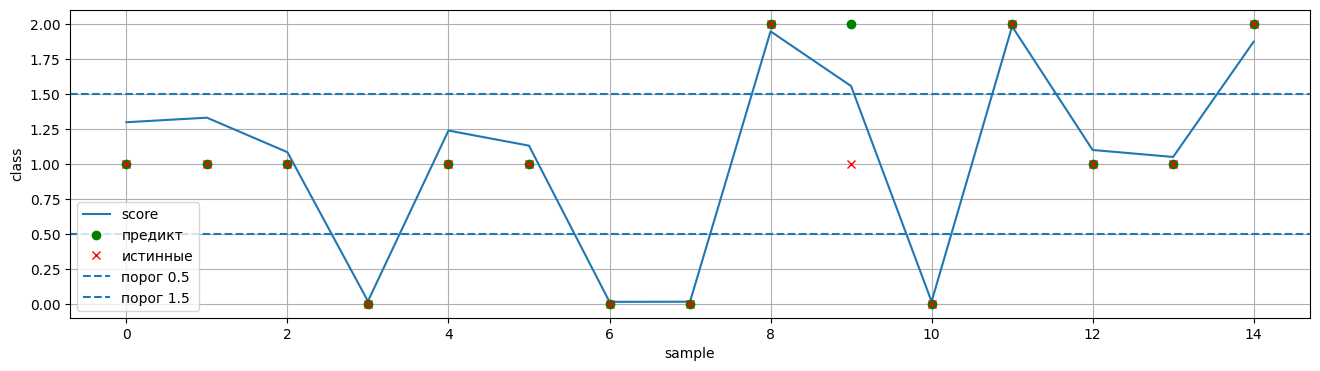

In [20]:
plt.figure(figsize=(16, 4))

plt.plot(score, label='score')
plt.plot(y_p, 'og', label='предикт')
plt.plot(y_test_tr, 'xr', label='истинные')

plt.axhline(0.5, linestyle='--', label='порог 0.5')
plt.axhline(1.5, linestyle='--', label='порог 1.5')

plt.grid()
plt.xlabel('sample')
plt.ylabel('class')
plt.legend()
plt.show()

In [21]:
print(classification_report(y_test_tr, y_p))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.88      0.93         8
           2       0.75      1.00      0.86         3

    accuracy                           0.93        15
   macro avg       0.92      0.96      0.93        15
weighted avg       0.95      0.93      0.94        15



В данной задаче используется 3 класса, поэтому одного порога недостаточно. Для разделения на три класса используется 2 порога. Значения выбраны как середины между соседними классами

В результате было правильно классифицировано 93% объектов тестовой выборки

#4 Самостоятельно оценить данные по варианту


### Вариант: V4 = datasets.make_classification(n_samples = 1000, n_features=10, n_redundant=2, n_informative=2,random_state=10, n_clusters_per_class=2)

#4.1 Загрузить данные по варианту

In [22]:
from sklearn import datasets

X, y = datasets.make_classification(
    n_samples=1000,
    n_features=10,
    n_redundant=2,
    n_informative=2,
    random_state=10,
    n_clusters_per_class=2
)

print(X.shape)
print(y.shape)
print(np.unique(y))

(1000, 10)
(1000,)
[0 1]


#4.2 Провести формирование классификатора для набора по своему варианту

In [23]:
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X, y, test_size=0.2, random_state=1)
X_val_tr, X_test_tr, y_val_tr, y_test_tr = train_test_split(X_test_tr, y_test_tr, test_size=0.5, random_state=1)

lr = LogisticRegression()
lr.fit(X_train_tr, y_train_tr)
y_pred = lr.predict_proba(X_val_tr)

tr = 0.5
y_p = (y_pred[:, 1] > tr).astype(int)
print(y_p)
print(y_val_tr)
accuracy = accuracy_score(y_val_tr, y_p)
print(accuracy)

acc = []

for tr in np.linspace(0, 1, 100):
    y_p = (y_pred[:, 1] > tr).astype(int)

    accuracy = accuracy_score(y_val_tr, y_p)

    acc += [[tr, accuracy]]

acc = np.array(acc)

best = np.argmax(acc[:, 1])
best_trace = acc[best, 0]
best_accuracy = acc[best, 1]

y_p = (y_pred[:, 1] > best_trace).astype(int)

print("Лучший порог:", best_trace)

[0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1
 1 1 1 0 0 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 1 1 0]
[0 0 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0
 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 1
 1 1 1 0 0 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 0 0 1 0 0]
0.92
Лучший порог: 0.5353535353535354


#4.3 Определить вид метрики , который соответствует степени сбалансированности набора данных

In [24]:
print("Класс 0:", np.sum(y == 0))
print("Класс 1:", np.sum(y == 1))

Класс 0: 500
Класс 1: 500


В наборе даннных 100 объектов и 2 класса. Оба класса содержат по 500 объектов. Значит выборка сбалансирована. Для оценки качества классификатора можно использовать метрику Accuracy.

#4.4 Сравнить варианты классификатора по метрике

In [25]:
tol_values = [0.1, 0.01, 0.001]
iter_values = [10, 50, 100, 500, 1000, 5000]

results = []

for tol in tol_values:
    for max_iter in iter_values:
        lr = LogisticRegression(tol=tol, max_iter=max_iter)
        lr.fit(X_train_tr, y_train_tr)

        y_p = lr.predict(X_val_tr)
        accuracy = accuracy_score(y_val_tr, y_p)

        results.append([tol, max_iter, accuracy])

results = pd.DataFrame(
    results,
    columns=['tol', 'max_iter', 'accuracy']
)

results

,tol,max_iter,accuracy
0,0.100,10,0.91
1,0.100,50,0.91
2,0.100,100,0.91
3,0.100,500,0.91
4,0.100,1000,0.91
5,0.100,5000,0.91
6,0.010,10,0.92
7,0.010,50,0.92
8,0.010,100,0.92
9,0.010,500,0.92


#4.5 Cделать выводы о качестве для модели из задания 1 и sklearn на основе выбранной метрики

In [26]:
lr = LogisticRegression()
lr.fit(X_train_tr, y_train_tr)

y_pred_test = lr.predict_proba(X_test_tr)
y_p_1 = (y_pred_test[:, 1] > best_trace).astype(int)
accuracy_1 = accuracy_score(y_test_tr, y_p_1)

y_p_sklearn = lr.predict(X_test_tr)
accuracy_sklearn = accuracy_score(y_test_tr, y_p_sklearn)

print("Accuracy пороговой модели:", accuracy_1)
print("Accuracy sklearn:", accuracy_sklearn)

Accuracy пороговой модели: 0.9
Accuracy sklearn: 0.88


Ранее был сделан вывод,что набор является сбалансированным, в качестве метрики будет использоваться Accuracy. Для пороговой модели значение Accuracy составило 0.9, а для стандартного классификатора sklearn - 0.88. Следовательно, на данной тестовой выборке пороговая модель показала немного более высокую долю правильных классификаций, хоть и разница небольшая

#4.6 Сделать выводы о качестве модели

In [27]:
print(classification_report(y_test_tr, y_p_1))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91        55
           1       0.86      0.93      0.89        45

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



Модель показала достаточно хорошее качество классификации. На валидационной выборке значение Accuracy достигало 0.92, а на тестовой выборке около 0.88-0.90 в зависимости от способа классификации. Результаты на валидационной и тестовой выборках близки, поэтому модель сохраняет качество и на новых данных. Подбор порога с наибольшей точнстью  на валидационных данных позволил повысить Accuracy по сравнению со стандартным вариантом sklearn.

Модель конкретно решает поставленную задачу классификации